# 3 Linear Regression

Recall the `Advertising` dataset from Chapter 2, which contains `sales` for a particular product as a function of advertising budgets for `TV`, `radio`, and `newspaper` media. 

Suppose we're asked to develop a marketing plan that will result in high product sales. Here are some questions we might try to answer:

1. *Is there a relationship between advertising budget and sales?* If the evidence is weak, maybe no money should be spent on advertising. 
2. *How strong is the relationship between advertising budget and sales?* Does knowledge about budget provide info about sales?
3. *Which media are associated with sales?* 
4. *How large is the association between each medium and sales?*
5. *How accurately can we predict future sales?*
6. *Is the relationship linear?*
7. *Are there interaction effects among the advertising media?* Maybe spending $50k on TV and $50k on radio is associated with higher sales than spending $100k on either one individually. 

## 3.1 Simple Linear Regression

- An approach for predicting a quantitative response $Y\in\mathbb{R}$ on the basis of a single predictor variable $X\in\mathbb{R}$, assuming that the relationship is approximately linear: $$Y \approx \beta_0 + \beta_1 X.$$
- We use our training data to produce estimates $\hat{\beta_0}$ and $\hat{\beta_1}$ of the model parameters, and then we can predict future sales on the basis of TV advertising (if $Y$ represents `sales` and $X$ represents `TV`) by computing $$\hat{y} = \hat{\beta_0} + \hat{\beta_1}x.$$

### 3.1.1 Estimating the Coefficients
Let $\{(x_1,y_1)\}_{i=1}^n$ be the $n$ observation pairs consisting of a measurement of $X$ and a corresponding one of $Y$. Our goal is to obtain coefficient estimates $\hat{\beta_0}$ and $\hat{\beta_1}$ such that the linear model fits the data well, i.e. that the resulting line is as close as possible to the data points. 

There are multiple ways to measure "closeness", but the most common approach involves minimizing the sum of squared residuals:

Let $\hat{y_i} = \hat{\beta_0} + \hat{\beta_1}x_i$ be the prediction for $Y$ based on the $i$th value of $X$. Then $$e_i = y_i - \hat{y_i}$$ is the *$i$-th residual* or *error*. We define the *residual sum of squares (RSS)* as 
$$
\begin{aligned}
    \text{RSS} &= e_1^2 + \ldots + e_n^2\\
    &= \sum_{i=1}^n (\hat{y_i} - \hat{\beta_0} - \hat{\beta_1}x_i)^2.
\end{aligned}    
$$

The **least squares** approach chooses the parameters $\hat{\beta_0}$ and $\hat{\beta_1}$ to minimize the RSS. Using calculus, it can be shown that the minimizers are 
$$
\begin{aligned}
    \hat{\beta_1} &= \frac{\sum_{i=1}^n(x_i - \overline{x})(y_i-\overline{y})}{\sum_{i=1}^n(x_i - \overline{x})}\\
    &= \frac{\widehat{\text{Cov}}(X,Y)}{\widehat{\text{Var}}(X)},\\
    \hat{\beta_0} &= \overline{y} - \hat{\beta_1}\overline{x}, 
\end{aligned}
$$
where $\overline{x}$ and $\overline{y}$ are the sample means of $x_i$ and $y_i$, respectively, $\widehat{\text{Cov}}(X,Y)$ is the sample covariance of $x_i$ and $y_i$, and $\widehat{\text{Var}}(X)$ is the sample variance of $x_i$. 

### 3.1.2 Assessing the Accuracy of the Coefficient Estimates
- The analogy between linear regression and estimation of the mean of a random variable is apt based on the concept of *bias*: If we use the sample mean $\hat{\mu}$ to estimate the population mean $\mu$, this estimate is *unbiased* in the sense that $E(\hat{mu}) = \mu$, where the expectation is taken over all possible sets of observations $\{y_1,\ldots,y_n\}$. Hence an unbiased estimator does not systematically over- or under-estimate the true parameter value. 
- Similarly, $\hat{\beta_i}$ are unbiased estimates of the true values of the $\beta_i$.

But how far off will a single estimate $\hat{\mu}$ be from $\mu$? We answer this by computing the *standard error* $\operatorname{SE}(\hat{\mu})of $\hat{\mu}$. We have $$\operatorname{Var}(\hat{\mu}) = \operatorname{SE}(\hat{\mu})^2 = \frac{\sigma^2}{n},$$ where $\sigma$ is the standard deviation of each of the realizations $y_i$ of $Y$. 

The standard error roughly indicates how far the estimate differs from the actual value. Note that the standard error decreases with more data points. 

Similarly, we can compute the standard error of $\hat{\beta_i}$ as follows.
$$
\begin{aligned}
    \operatorname{SE}(\hat{\beta_0})^2 &= \sigma_\epsilon^2\left(\frac{1}{n} + \frac{\overline{x}^2}{\sum_{i=1}^n(x_i - \overline{x})^2} \right),\\
    \operatorname{SE}(\hat{\beta_1})^2 &= \frac{\sigma_\epsilon^2}{\sum_{i=1}^n(x_i - \overline{x})^2},
\end{aligned}
$$
where $\sigma_\epsilon^2 = \operatorname{Var}\epsilon$.

For these formulas to be strictly valid, we need the assumption that the errors $\epsilon_i$ for each observation have common variance $\sigma_\epsilon^2$ and are uncorrelated. 

In general, $\sigma_\epsilon$ is unknown, but we can estimate the *residual standard error* by $$RSE = \sqrt{\frac{RSS}{n-2}}.$$ 

Standard errors can be used to compute **confidence intervals**. A 95% C.I. is defined as a range of values such that the range contains the true unknown value of the parameter with probability 95% in the following sense: if we take repated samples and construct the confidence interval for each sample, then 95% of the intervals will contain the true unknown value. 

For linear regression, the 95% C.I. for $\beta_i$ takes the form $$\hat{\beta_i} \pm 2\cdot\operatorname{SE}(\hat{\beta_i})$$ for $i=0,1$. 

Standard errors can also be used to perform *hypothesis tests* on the coefficients. The most common HT involves testing the *null hypothesis* of $$H_0: \beta_1 = 0$$ versus the *alternative hypothesis* $$H_a\beta_1 \neq 0.$$ These respectively correspond to saying that there is no relationship between $X$ and $Y$ or that there is some relationship between $X$ and $Y$. 

To test the null hypothesis, we need to determine whether our estimate for the slope parameter is sufficiently far from zero that we can be confident that it is non-zero. If $\operatorname{SE}(\hat{\beta_1})$ is small, then even relatively small values of $\hat{\beta_1}$ may provide strong evidence that $\beta_1\neq 0$, so we reject the null hypothesis.

Conversely, if $\operatorname{SE}(\hat{\beta_1})$ is large, then $\hat{\beta_1}$ must be large in absolute value in order for us to reject the null hypothesis. 

Practically, we compute a *t-statistic* $$ t = \frac{\hat{\beta_1}-0}{\operatorname{SE}(\hat{\beta_1})},$$ which measures the number of standard deviations that $\hat{\beta_1}$ is away from zero. 

See book for more details about this. 

### 3.1.3 Assessing the Accuracy of the Model
Once we've rejected the null hypothesis in favor of the alternative hypothesis, we need to quantify the extent to which the model fits the data. The quality of a linear regrression fit is assesed with the **residual standard error** (RSE) and the **$R$^2 statistic**. 

#### Residual Standard Error
Due to the presence of error terms in $y = \beta_0 + \beta_1x + \epsilon$, even if we knew the parameters exactly, we still wouldn't be able to perfectly predict $Y$ from $X$. The RSE is an estimate of the standard deviation of $\epsilon$. It is roughly the average amount that the response will deviate from the true regression line:
$$
RSE = \sqrt{\frac{1}{n-2}RSS} = \sqrt{\frac{1}{n-2}\sum_{i=1}^n(y_i - \hat{y_i})^2}.
$$

In the advertising data, if the RSE is 3.26, that means that actual sales in each market deviate from the true regression line by about 3260 units on average. Therefore even if the true values of the parameters were known, any prediction of sales on the basis of TV advertising would be off by 3260 units on average. The mean value of `sales` over all markets is 14,000, so the percentage error is 3260/14000 = 23%. 

The RSE measures the *lack of fit* of the model to the data. 

#### $R^2$ Statistic
Since RSE is measured in the units of $Y$, it's not always clear what constitutes a good RSE since it's an absolute measure of the lack of fit of the linear model to the data. The $R^2$ provides an alternative, relative measure of fit in the form of a proportion (the proportion of variance explained) and is always between 0 and 1:
$$ 
R^2 = \frac{TSS - RSS}{TSS} = 1-\frac{RSS}{TSS},
$$
where $TSS = \sum(y_i - \overline{y})^2$ is the *total sum of squares*. 

TSS measures the total variance in the response $Y$ and can be thought of as the amount of variability inherent in the response before the regression is performed. RSS measures the amount of variability that is left unexplained after performing the regression. Hence TSS - RSS measures the variability in the response that is explained by performing the regression, and $R^2$ measures the *proportion of variability in $Y$ that can be explained using $X$*. 

Despite its interpretational advantage over RSE, it can still be challenging to determine a good value of $R^2$. 

Both $R^2$ and the *correlation coefficient* $r$ measure the strength of the linear relationship between $X$ and $Y$. In simple linear regression, it can be shown that $R^2 = r^2$. However this doesn't extend to the multiple linear regression, in which case $R^2$ should be used (correlation is only defined between a single pair of variables). 

## 3.2 Multiple Linear Regression
Predicts a response using multiple predictor variables. Suppose we have $p$ distinct predictors. The multiple linear regression model takes the form $$Y = \beta_0 + \beta_1 X_1 + \ldots + \beta_p X_p + \epsilon.$$ We interpret $\beta_j$ as the *average* effect on $Y$ from a one unit increase in $X_j$, *holding all other predictors fixed*. 

### 3.2.1 Estimating the Regression Coefficients
Given parameter estimates $\hat{\beta_j}$, we can make predictions using $$\hat{y} = \hat{\beta_0} + \hat{\beta_1}x_1 + \ldots + \hat{\beta_j}x_j.$$ We estimate these parameters using the same least squares approach, i.e. we choose parameters to minimize the RSS $$RSS = \sum_{i=1}^n (y_i - \hat{y_i})^2.$$

In general, performing multiple linear regression on all the predictors can lead to different parameter estimates than performing simple linear regression on each of the predictors individually. This occurs when predictors are strongly correlated with one another. Consider the following example.

Running a regression of shark attacks on ice cream sales at a beach community over time would show a positive relationship between attacks and ice cream sales. A simple linear regression would show an association between these two variables. However, higher temps cause more people to visit the beach, which in turn increases both ice cream sales and shark attacks. A multiple regression of shark attacks on temperature and ice cream sales would reveal that ice cream sales were no longer a significant predictor, after adjusting for temperature. 

### 3.2.2 Some Important Questions
1. *Is at least one of the predictors $X_1, \ldots, X_p$ useful in predicting the response?*
2. *Do all the predictors help to explain $Y$, or is only a subset of them helpful?*
3. *How well does the model fit the data?*
4. *Given a set of predictor values, what response value should we predict, and how accurate is our prediction?*

#### 1: Is there a relationship between the response and the predictors? 
We test the hypothesis $$H_0: \beta_1 = \beta_2 = \ldots = \beta_p =0$$ versus the alternative $$H_a: \text{at least one } beta_j\neq0$$ for $j=1,\ldots,p$. This hypothesis test is performed by computing the *F-statistic* $$F = \frac{(TSS-RSS)/p}{RSS/(n-p-1)},$$ where $TSS = \sum_{i=1}^n (y_i - \overline{y})$. 

If the linear model assumptions are correct, one can show that $E[RSS/(n-p-1)] = \sigma^2$ and, provided that $H_0$ is true, $E[(TSS-RSS)/p] = \sigma^2$. Hence when there's no relationship between the predictors and response, we expect the $F$-statistic to be close to 1. On the other hand, if $H_a$ is true, then $E[(TSS-RSS)/p] > \sigma^2$ so we expect $F$ to be greater than 1. 

How much larger than 1 does $F$ need to be in order for us to reject $H_0$? Depends on $n$ and $p$. Large $n$ means we can get away with an $F$ that's closer to 1. 

#### 2: Deciding on important variables
The first step in a multiple regression analysis is to compute the F-statistic and examine the associated p-value.

If we conclude based on that p-value that at least one of the predictors is related to the response, we might wonder which ones. The process of determining which predictors are associated with the response is *variable selection* (see Ch. 6).

If we compare different models, we can select the best one using Mallow's $C_p$, AIC, BIC, adjusted $R^2$. But we can't check every possible subset of predictors. Instead we have the following approaches:
1. *Forward selection*. We begin with the null model (intercept only, no predictors). Then fit $p$ simple linear regressions, one on each predictor, and add to the null model the variable corresponding to the lowest RSS. This continues until some stopping rule is triggered. 
2. *Backward selection*. We start with all variables in the model, and remove the variable with the largest $p$-value, i.e. the one that's least statistically significant. The new $(p-1)$-variable model is fit and the process repeats until e.g. all remaining variables have a p-value below some threshold.
3. *Mixed selection*. Combo of forward and backward. 

Backward selection can't be used if $p>n$, but forward selection is a greedy approach so can always be used. However, forward selection can include variables early that might become redundant later. Mixed selection fixes this. 

### 3: Model Fit
Two common numerical measures of model fit are RSE and $R^2$, the proportion of variance explained by the linear model. 

In simple linear regression, $R^2$ was the square of the correlation coefficient between the predictor and the response. In multiple linear regression, it equals $\operatorname{Cor}(Y, \hat{Y})^2$, the square of the correlation between the response and the fitted linear model. 

Note that $R^2$ will always increase when more variables are added to the model, even if those variables are only weakly associated with the response. This is because adding another variable always decreases the residual sum of squares on the training data (though not necessarily the test data) due to overfitting. The same cannot be said of RSE. 

In addition to these two measures, it can be helpful to plot the data. 

#### 4: Predictions
Once we fit the multiple regression model, prediction is straightforward. However there are three sorts of uncertainty associated with these predictions. 
1. The parameter estimates $\hat{\beta_j}$ are only estimates for the true population regression coefficients $\beta_j$. The inaccuracy in parameter estimates is related to the reducible error, and we can compute a confidence interval to determine how close the predicted value will be from the true value. 
2. We assume that the true relationship is linear, which is almost always just an approximation. So there's an additional source of potentially reducible error that we call *model bias*. 
3. Even if we knew the true function and parameters, we still have the random irreducible error term $\epsilon$ in the model. How much will $Y$ vary from $\hat{Y}$? We use *prediction intervals* to answer this.

## 3.3 Other Considerations in the Regression Model
### 3.3.1 Qualitative Predictors
#### Predictors with only two levels
For a binary qualitative predictor (aka a factor), we simply create an indicator or dummy variable taking on values 0 and 1 or -1 and 1. The coding scheme is arbitrary and doesn't affect the regression fit, but it does affect the interpretation.

#### Qualitative Predictors with more than two levels
Here we can create additional dummy variables. There will always be one fewer dummy variable than the number of levels. $p$-values will depend on the coding scheme, but the $F$ statistic and its $p$ value wont. 

### 3.3.2 Extensions of the Linear Model 

Two of the most important assumptions of standard linear regression are that the relationship between predictors and response is additive and linear.

#### Removing the Additive Assumption
In the Advertising data, we concluded that both `TV` and `radio` are associated with `sales`. The linear model assumed that the effect of increasing one advertising medium is based on the corresponding parameter value alone, regardless of the amount spent on the other medium. It may be that spending money on radio advertising increases the effectiveness of TV advertising as well, so that the slope terms are not constant. This is called an *interaction effect*. 

One way of extending the linear model is to include an interaction term by multiplying two predictors together, resulting in $$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_1 X_2 + \epsilon.$$

It is sometimes the case that an interaction term has a very small p-value, whereas the main effects (standard variables) do not. The *hierarchical principle states that if we include an interaction in a model, we should also include the main effects, even if the p-values associated with their coefficients are not significant*. This is because if the interaction term is related to the response, then it's of little interest whether or not the coefficients of the main effects are exactly zero. Furthermore, the interaction is typically correlated with the main effects, so leaving them out alters the meaning of the interaction. 

#### Non-linear Relationships
**Polynomial regression**. 

A simple approach for incorporating non-linear associations in a linear model is to include transformed versions of the predictors, e.g. $X_1$ and $X_1^2$. A model of this type is still linear in the parameters and so we can use standard linear regression to estimate them, producing a non-linear fit. 

See Ch. 7 for more. 

### 3.3.3 Potential Problems
1. Non-linearity of the response-predictor relationships
2. Correlation of error terms
3. Non-constant variance of error terms
4. Outliers
5. High-leverage points
6. Collinearity

#### 1: Non-linearity of the data
If the true relationship is non-linear, then the conclusions that we draw from a linear fit are suspect and the prediction accuracy can be way off. 

*Residual plots* are a useful graphical tool for identifying non-linearity. 
- Simple linear regression: plot the residuals $e_i$ against the predictor $x_i$
- Multiple linear regression: plot the residuals $e_i$ against the predicted values $\hat{y_i}$. 
The presence of a pattern in the plot may indicate a problem with some aspect of the linear model.

One remedy is to include non-linear transformations of the predictors such as $\log X$, $\sqrt{X}$, $X^2$, etc. 

#### 2. Correlation of Error Terms
If there's correlation among the residuals, then the estimated standard errors for the regression coefficients or the fitted values will tend to underestimate the true standard errors. Thus confidence intervals and prediction intervals will be narrower than they should be. Also, p-values will be lower than they should be, leading to erroneous conclusions about statistical significance.

Correlations amongst error terms frequently occur in time series data.

They can also occur in e.g. a study recording individual's heights and weights. The errors could be correlated if some of them are members of the same family, eat the same diet, are exposed to the same environmental factors, etc. 

#### 3. Non-constant Variance of Error Terms
Another important assumption is that $\operatorname{Var}\epsilon_i = 0$. The standard errors, confidence intervals, and hypothesis tests associated with the linear model rely upon this assumption.  

One can identify non-constant variance of the error terms, or *heteroscedasticity*, from the presence of a funnel shape in the residual plot. 

One possible solution is to transform the response $Y$ with a concave function such as $\log Y$ or $\sqrt{Y}$, leading to a greater amount of shrinkage of the larger responses. 

#### 4. Outliers
It's typical for an outlier that does not have an unusual predictor value to have little effect on the least squares fit. However, the outlier can still cause other problems like inflating the RSE and decreasing $R^2$, which leads to further problems in confidence intervals and p-values. 

Outliers can be idenfitied with residual plots, but in practice it can be difficult to decide on a threshold before we consider the point to be an outlier. To address this, we plot the *studentized* residuals instead, computed by dividing each residual by its estimated standard error. Observations with studentized residuals greater than 3 in absolute values are possible outliers. 

#### 5. High Leverage Points
Observations with *high leverage* have an unusual value for $x_i$.

Removing a high-leverage point has a more substantial effect on the least squares line than removing the outlier. 

In a multiple linear regression with many predictors, it's possible to have an observation that is well within the range of each individual predictor's values but that is unusual in terms of the full set of predictors. 

To quantify leverage we compute the *leverage statistic*. A large value indicates an observation with high leverage. See book for formula. The leverage statistic is always between $1/n$ and 1, and the average leverage for all observations is equal to $(p+1)/n$. 

#### 6. Collinearity
Refers to the situation where two or more predictors are closely related to one another. Collinearity poses a problem for regression because it can be difficult to separate out the individual effects of collinear variables on the response.

it also reduces the accuracy of the estimates of the regression parameters and causes the standard error for $\hat{\beta_j}$ to grow. 

We also may fail to reject the null hypothesis $H_0: \beta_j = 0$, so the power of the hypothesis test is reduced by collinearity. 

A simple way to detect collinearity is to look at the correlation matrix of the predictors. An element that's large in absolute value indicates highly correlated variables and therefore a collinearity problem. But, not all collinearity problems can be detected this way. For instance, three variables can be collinear even if no pair has particularly high correlation (*multicollinearity*).

A better way to assess multicollinearity is to compute the *variance inflation factor*, which is the ratio of the variance of $\hat{\beta_j}$ when fitting the full model divided by the variance of $\hat{\beta_j}$ if fit on its own. A VIF value that exceeds 5 or 10 is a rule of thumb indicating problematic collinearity.
$$
\operatorname{VIF}(\hat{\beta_j}) = \frac{1}{1-R_{X_j|X_{-j}}^2},
$$ 
where $R_{X_j|X_{-j}}^2$ is the $R^2$ from a regression of $X_j$ onto all of the other predictors. 

Two solutions to collinearity: first is to drop one of the problematic variables from the gression. Second is to combine the collinear variables together into a single predictor, like taking their average. 

## 3.4 The Marketing Plan 
Now return to the seven questions about the Advertising data we asked at the beginning of the chapter. 
1. *Is there a relationship between sales and advertising budget?* This can be answered by multiple regression and testing the hypothesis that all three slope terms are zero. In table 3.6, the p-value corresponding to the F-statistic is very low, indicating clear evidence of a relationship. 
2. *How strong is the relationship?* The RSE estimates the std dev of the response from the population regression line. The $R^2$ statistic records the percentage of variability in the response that's explained by the predictors. 
3. *Which media are associated with sales?* To answer this, we examine the p-values associated with each predictor's t-statistic. If one is high, this suggests that that predictor is not associated with sales. 
4. *How large is the association between each medium and sales?* 
5. *How accurately can we predict future sales?*
6. *Is the relationship linear?* Residual plots can be used to identify non-linearity.
7. *Are there interaction effects among the advertising media?* A small p-value associated with the interaction term indicates the presence of such relationships. 

## 3.5 Comparison of Linear Regression with K-Nearest Neighbors
Linear regression is parametric, KNN regression is non-parametric.

Given a value for $K$ and a prediction point $x_0$, KNN regression identifies the $K$ training observations that are closest to $x_0$, represented by $N_0$. It then estimates $f(x_0)$ using the average of all the training responses in $N_0$: $$\hat{f}(x_0) = \frac{1}{K}\sum_{x_i\in N_0} y_i.$$ 

The optimal value for $K$ depends on the bias variance tradeoff: A small $K$ provides the most flexible fit and will have low bias but high variance. The high variance is due to the fact that the prediction in a given region is entirely dependent on one observation. In contrast, larger values of $K$ provide a smoother and less variable fit; the prediction in a region is an average of several points, so changing one observation has a smaller effect. However, the smoothing may cause bias by masking some of the structure in $f(X)$.

A parametric approach like linear regression will outperform a non-parametric approach like KNN regression if the parametric form that has ben selected is close to the true form of $f$. 

In practice, even when the true relationship is highly non-linear, KNN may still be inferior to linear regression. In higher dimensions, KNN often performs worse than linear regression due to the curse of dimensionality. 

For small dimensions, if the test MSE of KNN is only slightly lower than that of linear regression, we might be willing to forego a little prediction accuracy in favor of simplicity, interpretability, and for which p-values are available. 

## 3.6 Lab: Linear regression

### 3.6.1 Package imports

In [1]:
import numpy as np 
import pandas as pd
from matplotlib.pyplot import subplots

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize, poly) 

### 3.6.2 Simple Linear regression

`Boston` records the `medv` median house value for 506 neighborhoods in Boston. 

In [2]:
boston = load_data('Boston')
boston.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='object')

In [3]:
boston?

Type:        DataFrame
String form:
crim    zn  indus  chas    nox     rm   age     dis  rad  tax  \
           0    0.00632  18.0   2.3 <...> 0   5.64  23.9
           504     21.0   6.48  22.0
           505     21.0   7.88  11.9
           
           [506 rows x 13 columns]
Length:      506
File:        ~/isl-python/.venv/lib/python3.12/site-packages/pandas/core/frame.py
Docstring:  
Two-dimensional, size-mutable, potentially heterogeneous tabular data.

Data structure also contains labeled axes (rows and columns).
Arithmetic operations align on both row and column labels. Can be
thought of as a dict-like container for Series objects. The primary
pandas data structure.

Parameters
----------
data : ndarray (structured or homogeneous), Iterable, dict, or DataFrame
    Dict can contain Series, arrays, constants, dataclass or list-like objects. If
    data is a dict, column order follows insertion-order. If a dict contains Series
    which have an index defined, it is aligned by its i

Use `sm.OLS()` to fit a simple linear regression with predictor `lstat` (percent of households in that neighborhood with low socioeconomic status) and response `medv` (median house value in that neighborhood).

In [4]:
boston.shape

(506, 13)

For this model, we can create the predictor matrix by hand:

In [5]:
X = pd.DataFrame({
    'intercept': np.ones(len(boston)),
    'lstat': boston['lstat'],
})

X.head()

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94
4,1.0,5.33


Extract the response and fit the model:

In [6]:
y = boston['medv']

model = sm.OLS(y, X)
results = model.fit()

In [7]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Thu, 05 Mar 2026   Prob (F-statistic):           5.08e-88
Time:                        17:12:52   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     34.5538      0.563     61.415      0.000      33.448      35.659
lstat         -0.9500      0.039    -24.528      0.000      -1.026      -0.874
==============================================================================
Omnibus:                      137.043   Durbin-Watson:                   0.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              291.373
Skew:                           1.453   Prob(JB):                     5.36e-64
Kurtosis:                       5.319   Cond. No.                         29.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

We may wish to transform some variables before fitting the model, specify interaction terms, and expand some variables into polynomial terms. `sklearn` has a transform, which is an object with two main methods: `fit()` and `transform()`.

`ModelSpec()` creates a transform object, then a pair of methods `transform()` and `fit()` are used to construct a corresponding model matrix. The transform is created by the expression `design = MS(['lstat'])`. 

In [8]:
design = MS(['lstat'])
design = design.fit(boston)
X = design.transform(boston)
X.head()

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94
4,1.0,5.33


We can combine the fit and transform in one:

In [9]:
design = MS(['lstat'])
X = design.fit_transform(boston)
X.head()

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94
4,1.0,5.33


In [10]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Thu, 05 Mar 2026   Prob (F-statistic):           5.08e-88
Time:                        17:12:52   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     34.5538      0.563     61.415      0.000      33.448      35.659
lstat         -0.9500      0.039    -24.528      0.000      -1.026      -0.874
==============================================================================
Omnibus:                      137.043   Durbin-Watson:                   0.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              291.373
Skew:                           1.453   Prob(JB):                     5.36e-64
Kurtosis:                       5.319   Cond. No.                         29.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [11]:
results.params

intercept    34.553841
lstat        -0.950049
dtype: float64

In [12]:
new_df = pd.DataFrame({
    'lstat': [5, 10, 15],
})
newX = design.transform(new_df)
newX

,intercept,lstat
0,1.0,5
1,1.0,10
2,1.0,15


In [13]:
new_predictions = results.get_prediction(newX)
new_predictions.predicted_mean

array([29.80359411, 25.05334734, 20.30310057])

In [14]:
new_predictions.conf_int(alpha=0.05)

array([[29.00741194, 30.59977628],
       [24.47413202, 25.63256267],
       [19.73158815, 20.87461299]])

In [15]:
new_predictions.conf_int(obs=True, alpha=0.05)

array([[17.56567478, 42.04151344],
       [12.82762635, 37.27906833],
       [ 8.0777421 , 32.52845905]])

In [16]:
def abline(ax, b, m, *args, **kwargs):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim, *args, **kwargs)

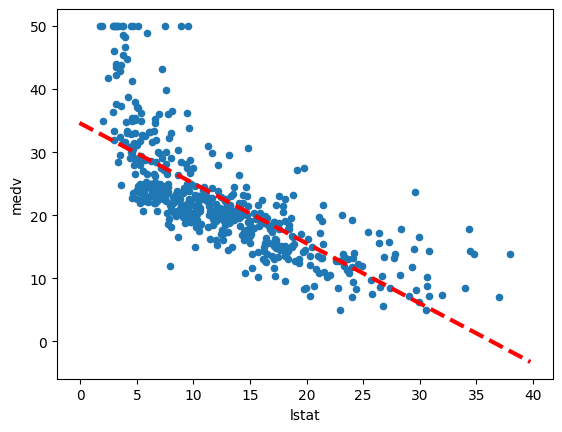

In [17]:
ax = boston.plot.scatter(x='lstat', y='medv')
abline(ax, results.params['intercept'], results.params['lstat'], 'r--', linewidth=3) 

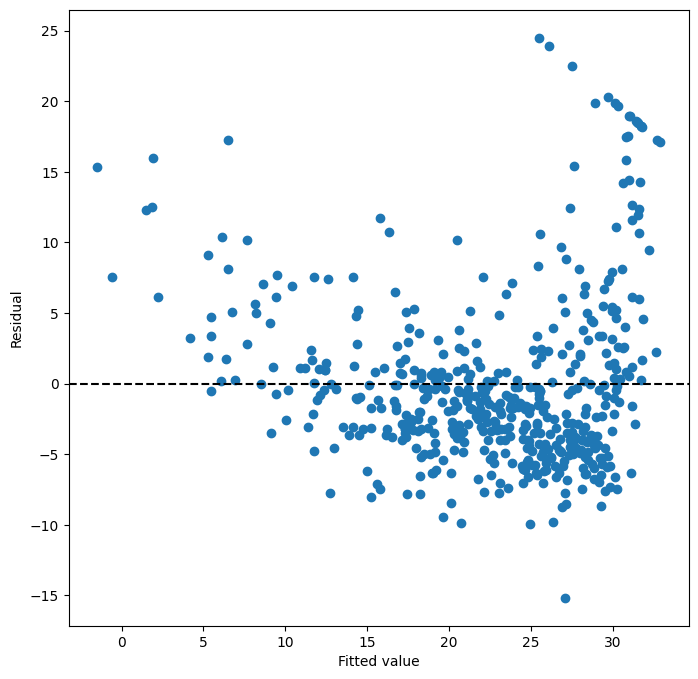

In [18]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results.fittedvalues , results.resid) 
ax.set_xlabel('Fitted value') 
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--')

np.int64(374)

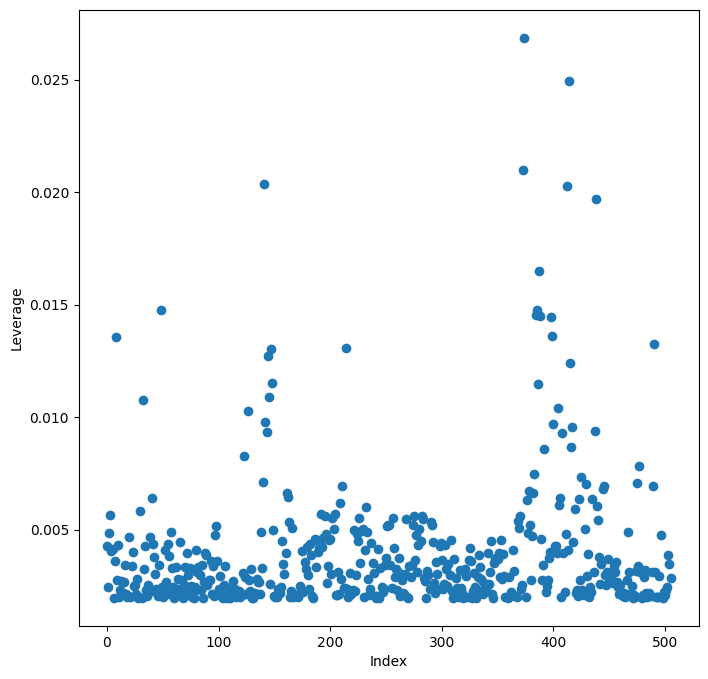

In [19]:
infl = results.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag) 
ax.set_xlabel('Index')
ax.set_ylabel('Leverage') 
np.argmax(infl.hat_matrix_diag)

### 3.6.3 Multiple Linear Regression

## 3.7 Exercises

### Conceptual

#### 1

Null hypotheses, in plain terms:
- **Intercept**: When all media spending for each of the different media types are held fixed at zero, we expect there to be no sales. This corresponds to $H_0: \beta_0 = 0$. Since the p-value is very small, we reject the null hypothesis and conclude that we can expect baseline sales to be around 2939 units even with zero marketing spends in the three media types. 
- **TV**: Holding other media spending fixed yet arbitrary, we expect there to be no relationship between TV spending and sales. This corresponds to $H_0: \beta_{TV} = 0$. Since the p-value is very small, we reject the null hypothesis and conclude that holding radio and newspaper spending fixed, we can expect 46 units to be sold for every $1,000 spent on TV advertising. 
- **radio**: Holding other media spending fixed yet arbitrary, we expect there to be no relationship between radio spending and sales. This corresponds to $H_0: \beta_{radio} = 0$. Since the p-value is very small, we reject the null hypothesis and conclude that holding TV and newspaper spending fixed, we can expect 189 units to be sold for every $1,000 increase in radio spending.
- **newspaper**: Holding other media spending fixed yet arbitrary, we expect there to be no relationship between newspaper spending and sales. This corresponds to $H_0: \beta_{newspaper} = 0$. Since the p-value is quite large, we fail to reject the null hypothesis. Thus we conclude that holding TV and radio spending fixed, there is no expected association between newspaper advertising and sales. 

#### 2

The KNN classifier is used for classification tasks (the response is a discrete variable) while the KNN regression method is used for regression tasks (the response is a continuous quantitative variable). The KNN classifier classifies a given test point $x_0$ according to the class that is seen most frequently amongst the point's $K$-nearest neighbors. Similarly, the KNN regression method estimates the response of a given test point $x_0$ as the *average* of the response values of the point's $K$-nearest neighbors. 

The role of $K$ is similar in both approaches: it characterizes the neighborhood which in turn determines the resulting surface in feature space. As such, with lower values of $K$, either method is vastly more flexible and will have lower bias but higher variance. Conversely, as $K$ grows, either method becomes less flexible and will have higher bias but lower variance. 

#### 3

- (a) iii: For a fixed value of IQ and GPA, high school graduates earn more, on average, than college graduates provided that the GPA is high enough.
- (b) 137,100
- (c) False. A statistical test evaluating the significance of the coefficient value is needed in order to serve as evidence for/against an interaction effect. The magnitude of the coefficient has more to do with producing the correct units in that the interaction term is on the order of hundreds to thousands (GPA times IQ) 

#### 4

- (a) The training RSS for the cubic regression is likely to be **smaller** than that of the linear regression. As a more flexible method, the cubic regression is more likely to overfit the data, since there are a relatively large number of observations (n=100) compared to the degree of the polynomial.
- (b) Conversely, the test RSS for cubic regression is more likely to be **larger** than that of the linear regression. Since the cubic regression probably overfit to the training data, it will perform worse on the test data. 
- (c) The training RSS for the cubic regression is likely to be **smaller** than that of linear regression as in part (a). This is due to the fact that the cubic regression is a strict generalization of the linear model, and include it as a special case with the coefficients of the quadratic and cubic terms equal to zero. 
- (d) Theres not enough information to tell. Depending on how far the true relationship is from linear, the cubic model may or may not overfit the data.

#### 5 

$$a_{i'} = \frac{x_i}{\sum_{j=1}^n x_j^2}\cdot x_{i'}.$$

#### 6

We'll show (using eq. 3.4) that in simple linear regression, the least squares line always passes through the point $(\overline{x}, \overline{y})$.

By 3.4, let $\hat{y_i} = \hat{\beta_0} + \hat{\beta_1}x_i$, where 
$$
\begin{aligned}
    \hat{\beta_0} &= \overline{y} - \hat{\beta_1}\overline{x},\\
    \hat{\beta_1} &= \frac{\sum_{i=1}^n (x_i - \overline{x})(y_i - \overline{y})}{\sum_{i=1}^n (x_i - \overline{x}^2)}.
\end{aligned}
$$

To show that the equation $\hat{y_i} = \hat{\beta_0} + \hat{\beta_1}x_i$ passes through $(\overline{x}, \overline{y})$, we simply plug in $x_i = \overline{x}$ and $y_i = \overline{y}$ to the equation and show that both sides are equal. On the left hand side, we immediately have $y_i = \overline{y}$. On the right-hand side, it's easy to see that plugging in those values to the expression for the slope parameter results in $\hat{\beta_1} = 0$. Therefore by the expression for the intercept term, we have $\beta_0 = \overline{y}$. Therefore we have $\overline{y} = \overline{y}$ on both sides.

#### 7

### Applied

#### 8

In [20]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
auto = pd.read_csv('./data/Auto.csv', na_values='?')        # These data have some missing values, which are marked with '?'
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


- (a) Use the `sm.OLS()` function to perform a simple linear regression with `mpg` as the response and `horsepower` as the predictor. Use the `summarize()` function to print the results. Comment on the output. For example:
    - i. Is there a relationship between the predictor and the response?
    - ii. How strong is the relationship between the predictor and the response?
    - iii. Is the relationship between the predictor and the response positive or negative?
    - iv. What is the predicted mpg associated with a horsepower of 98? What are the associated 95 % confidence and prediction intervals?

In [22]:
subset = auto[['mpg', 'horsepower']]
subset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   mpg         397 non-null    float64
 1   horsepower  392 non-null    float64
dtypes: float64(2)
memory usage: 6.3 KB


As you can see, there are five rows with `'?'`. We have to drop these from the dataframe in order to feed the data into the model. 

In [23]:
subset = subset.dropna()
subset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 396
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   mpg         392 non-null    float64
 1   horsepower  392 non-null    float64
dtypes: float64(2)
memory usage: 9.2 KB


In [24]:
X = subset['horsepower']
X = sm.add_constant(X) 

y = subset['mpg']

model = sm.OLS(y,X)
results = model.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Thu, 05 Mar 2026   Prob (F-statistic):           7.03e-81
Time:                        17:12:52   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         39.9359      0.717     55.660      0.000      38.525      41.347
horsepower    -0.1578      0.006    -24.489      0.000      -0.171      -0.145
==============================================================================
Omnibus:                       16.432   Durbin-Watson:                   0.920
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               17.305
Skew:                           0.492   Prob(JB):                     0.000175
Kurtosis:                       3.299   Cond. No.                         322.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

- (i) *Is there a relationship between the predictor and the response?*

The summary indicates that the p-value (`P>|t|`) for `horsepower` is very very small. Therefore we reject the null hypothesis that $\beta_{horsepower}= 0$ and conclude that there is a statistically significant association between the predictor and the response. Note that in this case, the F-statistic for the overall model is exactly the square of the t-statistic for the `horsepower` coefficient parameter, and so their p-values agree (For multiple linear regression this won't be the case). 

- (ii) *How strong is the relationship between the predictor and the response?*

Examine the $R^2$ and RSE values. We have $R^2 = 0.606$, meaning that roughly 61% of the variance in the `mpg` is explained by `horsepower`. The RSE is not directly shown, but can be computed as $\sqrt{\frac{1}{n-2}RSS}$:

In [25]:
rss = results.ssr
rss

np.float64(9385.915871932419)

In [26]:
rse = np.sqrt(rss / (X.shape[0] - X.shape[1]))
rse

np.float64(4.90575691954594)

An RSE of ~4.9 tells us that the model's predictions are off by about 4.9 mpg, on average. 

In [27]:
avg_mpg = subset['mpg'].mean()
print(f"Average MPG: {avg_mpg:.2f}")

percent_error = (rse / avg_mpg) * 100
print(f"RSE as a percentage of the average MPG: {percent_error:.2f}%")

Average MPG: 23.45
RSE as a percentage of the average MPG: 20.92%


With an average `mpg` of 23.45, the RSE of 4.9 implies that the model's typical error is about 21% of the average response. This, combined with $R^2 = 0.606$, means that we have a **moderately** strong relationship between predictor and response. 

- (iii) *Is the relationship between the predictor and the response positive or negative?*

Given the coefficient value of $-0.1578$, the relationship is negative. 

- (iv) *What is the predicted mpg associated with a horsepower of 98? What are the associated 95 % confidence and prediction intervals?*

$\hat{y}(98) = 39.9359 - 0.1578(98) = 24.5$ MPG. 

In [28]:
x0 = 98

prediction = results.get_prediction([1, x0])
prediction.predicted

array([24.46707715])

In [29]:
prediction.conf_int(alpha=0.05)          # confidence interval

array([[23.97307896, 24.96107534]])

In [30]:
prediction.conf_int(alpha=0.05, obs=True)   # prediction interval

array([[14.80939607, 34.12475823]])

- (b) Plot the response and the predictor in a new set of axes ax. Use the ax.axline() method or the abline() function defined in the lab to display the least squares regression line.

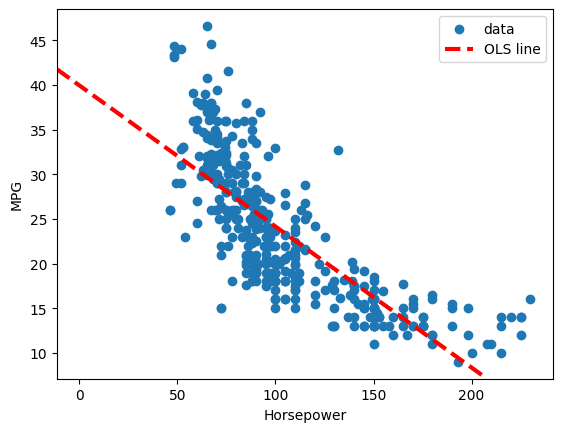

In [31]:
fig, ax = plt.subplots()
ax.scatter(x=subset['horsepower'], y=subset['mpg'], label='data')
ax.set_xlabel('Horsepower')
ax.set_ylabel('MPG')

ax.axline((0, results.params['const']), slope=results.params['horsepower'], color='red', linestyle='--', linewidth=3, label='OLS line')
ax.legend()
plt.show()

- (c) Produce some of diagnostic plots of the least squares regression fit as described in the lab. Comment on any problems you see with the fit.

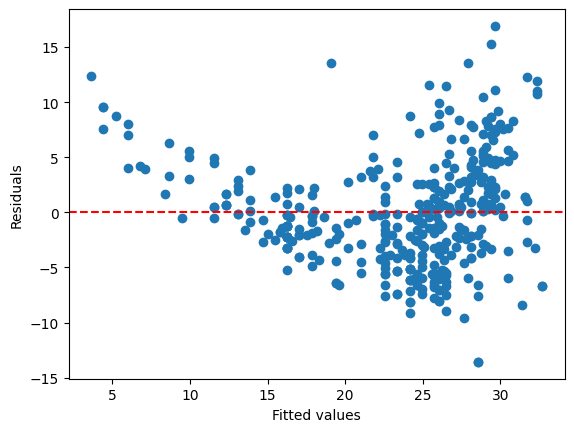

In [32]:
fig, ax = plt.subplots()
ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel('Fitted values')
ax.set_ylabel('Residuals')
ax.axhline(0, color='red', linestyle='--')
plt.show()

Based on the plot of residuals, there is evidence of non-linearity. 

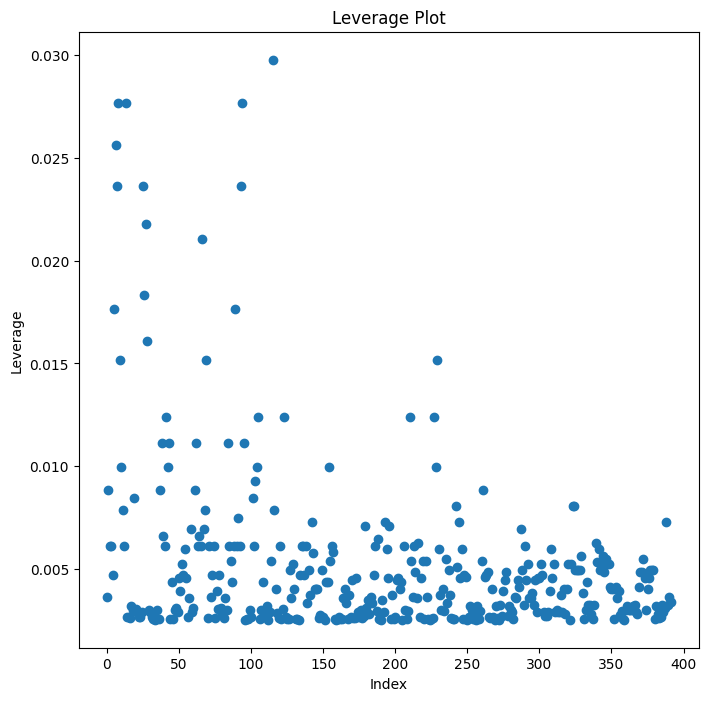

In [33]:
infl = results.get_influence()
ax = plt.subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag) 
ax.set_xlabel('Index')
ax.set_ylabel('Leverage') 
ax.set_title('Leverage Plot')
plt.show()

In [34]:
np.argmax(infl.hat_matrix_diag)

np.int64(115)

#### 9 
Multiple linear regression on the `Auto` data set. 

In [35]:
auto = pd.read_csv('./data/Auto.csv', na_values='?')
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


In [36]:
auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           397 non-null    float64
 1   cylinders     397 non-null    int64  
 2   displacement  397 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        397 non-null    int64  
 5   acceleration  397 non-null    float64
 6   year          397 non-null    int64  
 7   origin        397 non-null    int64  
 8   name          397 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 28.0+ KB


- (a) Produce a scatterplot matrix which includes all of the variables in the data set.

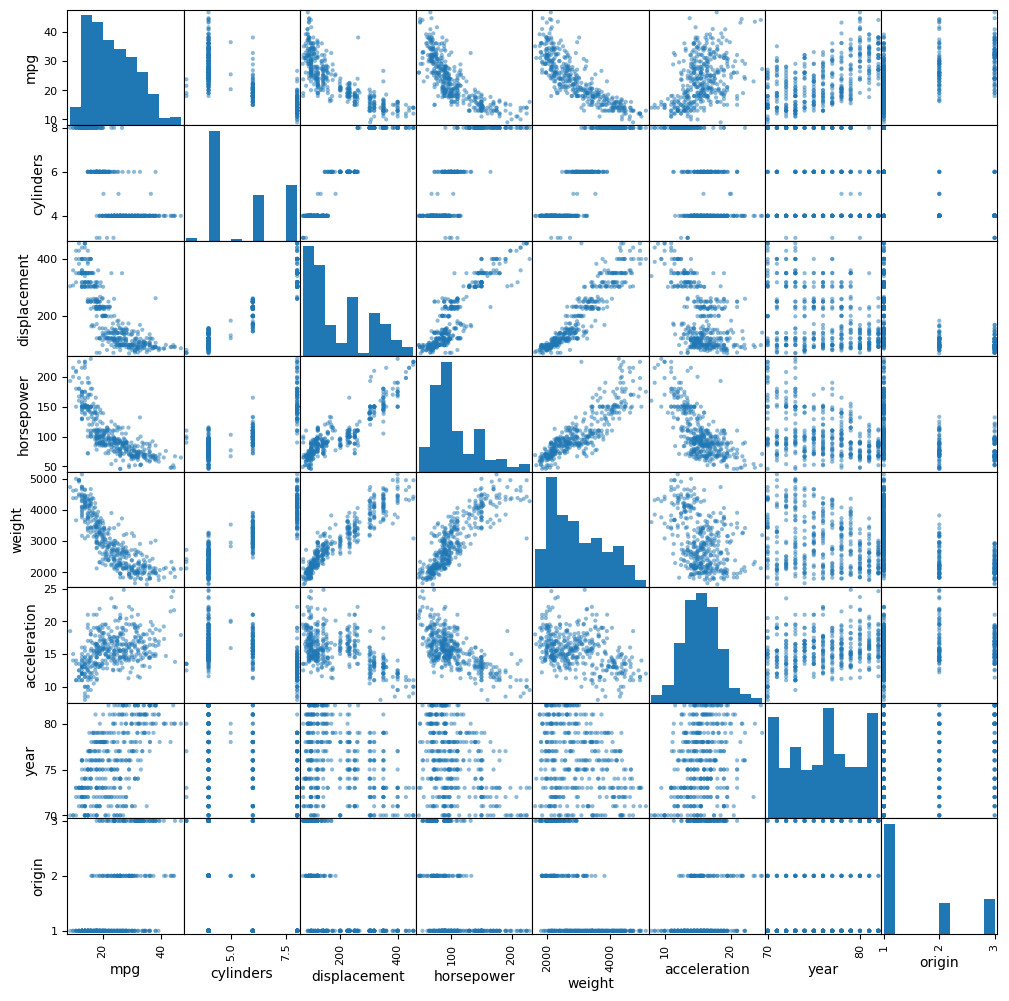

In [37]:
pd.plotting.scatter_matrix(auto, figsize=(12, 12))
plt.show()

- (b) Compute the matrix of correlations between the variables using the `DataFrame.corr()` method.

In [38]:
auto_no_name = auto.drop(columns='name')
auto_corr_matrix = auto_no_name.corr()

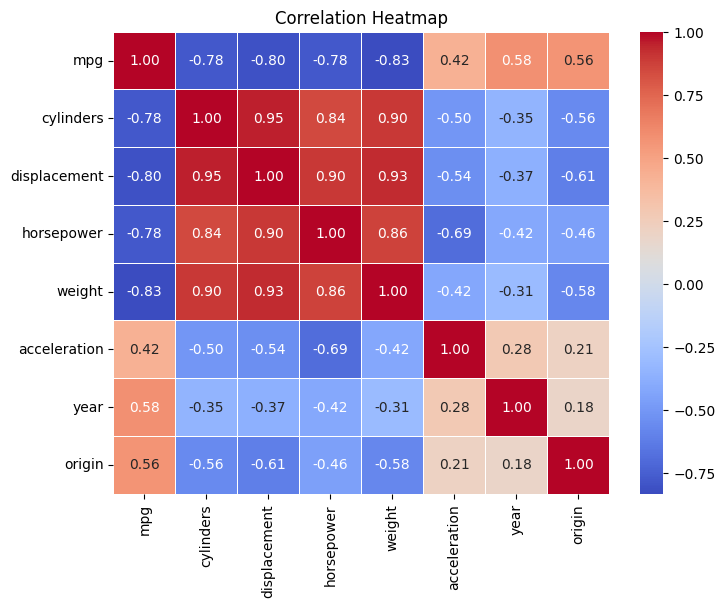

In [39]:
import seaborn as sns

plt.figure(figsize=(8, 6)) # Adjust figure size as needed
sns.heatmap(
    auto_corr_matrix,
    annot=True,       # Annotate cells with correlation values
    cmap='coolwarm',  # Choose a color map (e.g., 'coolwarm', 'viridis')
    fmt='.2f',        # Format the annotations to two decimal places
    linewidths=0.5    # Add lines between cells
)
plt.title('Correlation Heatmap')
plt.show()

- (c) Use the sm.OLS() function to perform a multiple linear regression with `mpg` as the response and all other variables except `name` as the predictors. Use the `summarize()` function to print the results. Comment on the output.

In [43]:
auto_drop_na = auto_no_name.dropna()

X = auto_drop_na.drop(columns='mpg')
X = sm.add_constant(X)

y = auto_drop_na['mpg']

model = sm.OLS(y,X)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Thu, 05 Mar 2026   Prob (F-statistic):          2.04e-139
Time:                        17:22:46   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -17.2184      4.644     -3.707      0.000     -26.350      -8.087
cylinders       -0.4934      0.323     -1.526      0.128      -1.129       0.142
displacement     0.0199      0.008      2.647      0.008       0.005       0.035
horsepower      -0.0170      0.014     -1.230      0.220      -0.044       0.010
weight          -0.0065      0.001     -9.929      0.000      -0.008      -0.005
acceleration     0.0806      0.099      0.815      0.415      -0.114       0.275
year             0.7508      0.051     14.729      0.000       0.651       0.851
origin           1.4261      0.278      5.127      0.000       0.879       1.973
==============================================================================
Omnibus:                       31.906   Durbin-Watson:                   1.309
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               53.100
Skew:                           0.529   Prob(JB):                     2.95e-12
Kurtosis:                       4.460   Cond. No.                     8.59e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.59e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

- i. Is there a relationship between the predictors and the response? Use the `anova_lm()` function from statsmodels to answer this question.

Based on the p-value corresponding to the model $F$-statistic, we reject the null hypothesis and conclude that there's a clear linear relationship betwen the predictors and the response. Using `anova_lm()` would involve first fitting a null model (intercept only) to the data and computing `anova_lm(results_null, results_full)` to compare the full model with the null model. However, the p-value for the $F$-statistic is based on exactly the same hypothesis test so in this case they are the same and we can just look at the $F$-statistic in `results.summary()`. 

- ii. Which predictors appear to have a statistically significant relationship to the response?

Based on the `results.summary()` output, it appears that `displacement`, `weight`, `year`, and `origin` all have statistically significant relationships to the response. 

- iii. What does the coefficient for the `year` variable suggest?

The coefficient for `year` suggests that, holding all other variables fixed, we expect to see an increase of 0.75 MPG for every incremental increase in `year`. 

- (d)